In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
data = pd.read_csv("dupType_numberPairs_Methyl(Sheet1).csv")

In [9]:
data.head()

,dupType,gbM_gbM,gbM_teM,gbM_uM,teM_teM,teM_uM,uM_uM,gbM_unk,teM_unk,uM_unk,unk_unk
0,ConfidentWGD,264,26,643,37,169,9267,81,48,1190,86
1,SameChrWGD,3,5,58,73,69,1736,64,64,1503,539
2,OtherWGD,176,20,432,80,137,5386,64,64,845,86
3,Proximal,4,14,81,358,285,2769,57,292,2098,1509
4,Tandem,2,3,35,42,61,1288,7,67,522,357


In [10]:
data['total_pairs'] = data[['gbM_gbM','teM_teM','gbM_teM','gbM_uM', 'uM_uM','teM_uM', 'gbM_unk', 'teM_unk', 'uM_unk', 'unk_unk']].sum(axis=1)

In [11]:
print(data)

        dupType  gbM_gbM  gbM_teM  gbM_uM  teM_teM  teM_uM  uM_uM  gbM_unk  \
0  ConfidentWGD      264       26     643       37     169   9267       81   
1    SameChrWGD        3        5      58       73      69   1736       64   
2      OtherWGD      176       20     432       80     137   5386       64   
3      Proximal        4       14      81      358     285   2769       57   
4        Tandem        2        3      35       42      61   1288        7   
5     Dispersed      210      134    2081     9055    2382  25129      533   
6    Transposed       31       60     330     1700     660   3771       82   

   teM_unk  uM_unk  unk_unk  total_pairs  
0       48    1190       86        11811  
1       64    1503      539         4114  
2       64     845       86         7290  
3      292    2098     1509         7467  
4       67     522      357         2384  
5     5689   11854     4368        61435  
6     1130    1738      720        10222  


In [12]:
data['percent_same'] = data[['gbM_gbM', 'teM_teM', 'uM_uM', 'unk_unk']].sum(axis=1) / data['total_pairs'] * 100
data['percent_diff'] = data[['gbM_teM', 'teM_uM', 'gbM_uM', 'gbM_unk', 'teM_unk', 'uM_unk']].sum(axis=1) / data['total_pairs'] * 100

In [13]:
print(data)

        dupType  gbM_gbM  gbM_teM  gbM_uM  teM_teM  teM_uM  uM_uM  gbM_unk  \
0  ConfidentWGD      264       26     643       37     169   9267       81   
1    SameChrWGD        3        5      58       73      69   1736       64   
2      OtherWGD      176       20     432       80     137   5386       64   
3      Proximal        4       14      81      358     285   2769       57   
4        Tandem        2        3      35       42      61   1288        7   
5     Dispersed      210      134    2081     9055    2382  25129      533   
6    Transposed       31       60     330     1700     660   3771       82   

   teM_unk  uM_unk  unk_unk  total_pairs  percent_same  percent_diff  
0       48    1190       86        11811     81.737363     18.262637  
1       64    1503      539         4114     57.146330     42.853670  
2       64     845       86         7290     78.573388     21.426612  
3      292    2098     1509         7467     62.140083     37.859917  
4       67     522  

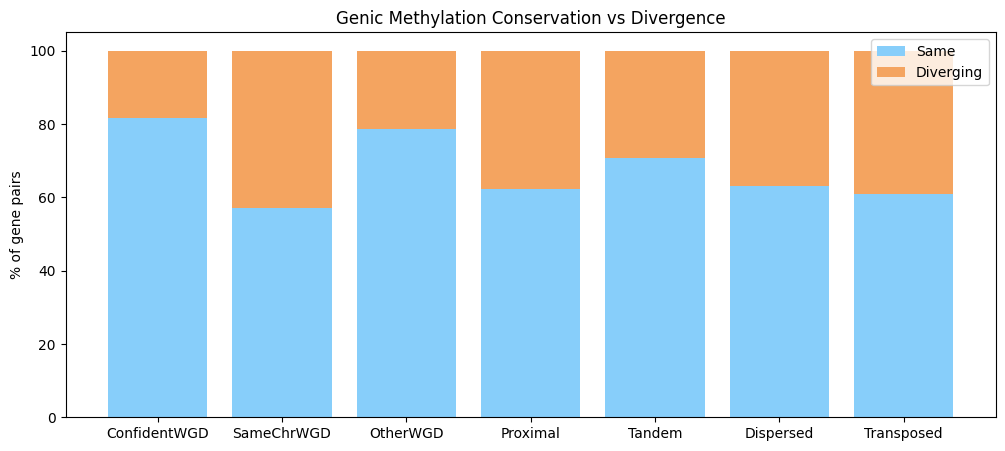

In [28]:
# Plot
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(data['dupType'], data['percent_same'], label='Same', color='lightskyblue')
ax.bar(data['dupType'], data['percent_diff'], bottom=data['percent_same'], label='Diverging', color='sandybrown')
ax.set_ylabel('% of gene pairs')
ax.set_title('Genic Methylation Conservation vs Divergence')
ax.legend()
plt.show()